# Figure demo

The cell below is tagged `#| label: figDemo`, which is what lets
`02-interactive-figures.md` embed its output with `:::{figure} #figDemo`.

This is Plotly's standard slider example. Replace it with your own work.

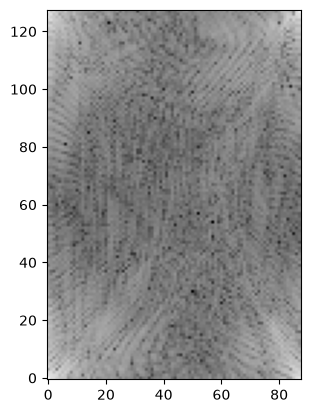

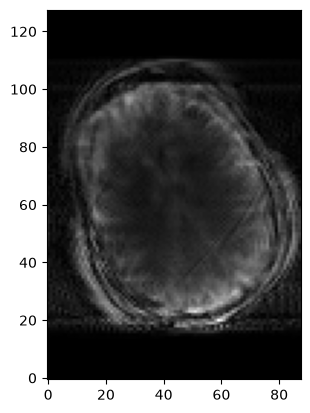

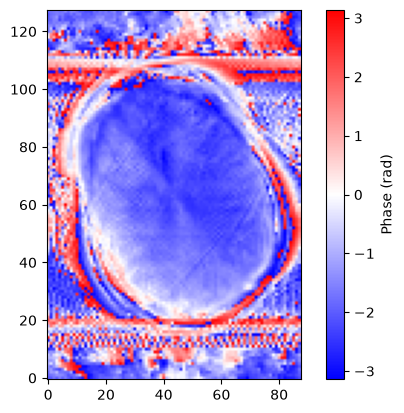

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
import nibabel as nib

PHASE = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz")
MAG = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz")

mag_data = (nib.load(MAG).get_fdata())[:,:,0]
phase_data = (nib.load(PHASE).get_fdata())[:,:,0] 
complex_img = mag_data * np.exp(1j * phase_data)
kspace = (np.fft.fft2(complex_img))
nx, ny = kspace.shape

#Assuming one full Ky line per TR
motion_start = 10   
motion_stop  = 70
totat_rot = 40 # deg
angle_rate   = totat_rot/(motion_stop-motion_start) #deg per line

lines = np.arange(nx)    
x_deg = np.arange(motion_stop-motion_start)   
deg = np.zeros(nx)
deg[(lines >= motion_start) & (lines < motion_stop)] = x_deg * angle_rate
kspace_rot = kspace.copy()

for i in lines[motion_start:motion_stop]:
    complex_img_rotated = (
        rotate(mag_data, deg[i], reshape=False, order=1)
        * np.exp(1j * rotate(phase_data, deg[i], reshape=False, order=1)))
    kspace_rot[i,:] = (np.fft.fft2((complex_img_rotated)))[i,:]
    
    #plt.imshow(np.abs(complex_img_rotated), cmap="gray", origin="lower")
    #plt.show()
    
for i in lines[motion_stop:]:
    complex_img_rotated = (
        rotate(mag_data, deg[motion_stop-1], reshape=False, order=1)
        * np.exp(1j * rotate(phase_data, deg[motion_stop-1], reshape=False, order=1)))
    kspace_rot[i,:] = (np.fft.fft2((complex_img_rotated)))[i,:]
    
   
img_motion = (np.fft.ifft2(kspace_rot))

plt.imshow(np.log(np.abs(kspace_rot)).T, cmap="gray", origin="lower")
plt.show()

plt.imshow(np.abs(img_motion.T), cmap="gray", origin="lower")
plt.show()

plt.imshow(np.angle(img_motion.T), cmap="bwr", vmin=-np.pi, vmax=np.pi,origin="lower")
plt.colorbar(label="Phase (rad)")
plt.show()

In [21]:
import numpy as np
import nibabel as nib
from scipy.ndimage import rotate
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from ipywidgets import interact, IntSlider, FloatSlider

PHASE = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz")
MAG = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz")

mag_data = (nib.load(MAG).get_fdata())[:, :, 0]
phase_data = (nib.load(PHASE).get_fdata())[:, :, 0]
complex_img = mag_data * np.exp(1j * phase_data)
kspace = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(complex_img)))  # FIX: centered k-space
nx, ny = kspace.shape


def update(motion_start=5, motion_stop=50, total_rot=1.0):
    motion_stop = max(motion_stop, motion_start + 1)  # FIX: avoid empty range / division by zero
    lines = np.arange(nx)
    x_deg = np.arange(motion_stop - motion_start)
    deg = np.zeros(nx)
    angle_rate = total_rot / max(motion_stop - motion_start - 1, 1)  # FIX: typo + sign, last line reaches total_rot
    deg[(lines >= motion_start) & (lines < motion_stop)] = x_deg * angle_rate

    kspace_rot = kspace.copy()
    for i in lines[motion_start:motion_stop]:
        # FIX: rotate real/imag instead of phase (no interpolation across ±pi wraps)
        complex_img_rotated = (
            rotate(complex_img.real, deg[i], reshape=False, order=1)
            + 1j * rotate(complex_img.imag, deg[i], reshape=False, order=1)
        )
        kspace_rot[i, :] = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(complex_img_rotated)))[i, :]

    # FIX: object stays at final angle -> rotate + FFT once, not once per line
    complex_img_rotated = (
        rotate(complex_img.real, deg[motion_stop - 1], reshape=False, order=1)
        + 1j * rotate(complex_img.imag, deg[motion_stop - 1], reshape=False, order=1)
    )
    kspace_rot[motion_stop:, :] = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(complex_img_rotated)))[motion_stop:, :]

    img_motion = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace_rot)))  # FIX: centered inverse

    # masks: 1 on the relevant lines, NaN elsewhere (NaN -> fully transparent in Heatmap)
    moving = np.full((nx, ny), np.nan)
    moving[motion_start:motion_stop, :] = 1      # green: object rotating during these lines

    rotated = np.full((nx, ny), np.nan)
    rotated[motion_stop:, :] = 1                  # red: object still, but at final angle
    fig = make_subplots(rows=2, cols=2,
                        subplot_titles=("k-space magnitude (log|.|)", "k-space phase",
                                        "Image magnitude", "Image phase"))

    # row 1: k-space
    fig.add_trace(go.Heatmap(z=np.log(np.abs(kspace_rot) + 1e-9).T,
                              colorscale="gray", showscale=False), row=1, col=1)
    fig.add_trace(go.Heatmap(z=moving.T, colorscale=[[0, "green"], [1, "green"]],
                              showscale=False, opacity=0.15, hoverinfo="skip"), row=1, col=1)
    fig.add_trace(go.Heatmap(z=rotated.T, colorscale=[[0, "yellow"], [1, "red"]],
                              showscale=False, opacity=0.15, hoverinfo="skip"), row=1, col=1)
    fig.add_trace(go.Heatmap(z=np.angle(kspace_rot).T, coloraxis="coloraxis"), row=1, col=2)
    fig.add_trace(go.Heatmap(z=moving.T, colorscale=[[0, "green"], [1, "green"]],
                              showscale=False, opacity=0.15, hoverinfo="skip"), row=1, col=2)
    fig.add_trace(go.Heatmap(z=rotated.T, colorscale=[[0, "red"], [1, "red"]],
                              showscale=False, opacity=0.15, hoverinfo="skip"), row=1, col=2)
    # row 2: image
    fig.add_trace(go.Heatmap(z=np.abs(img_motion).T, colorscale="gray", showscale=False), row=2, col=1)
    fig.add_trace(go.Heatmap(z=np.angle(img_motion).T, coloraxis="coloraxis"), row=2, col=2)

    for c, (r, col) in enumerate([(1, 1), (1, 2), (2, 1), (2, 2)], start=1):
        fig.update_yaxes(scaleanchor=f"x{c}" if c > 1 else "x", row=r, col=col)

    fig.update_layout(width=900, height=850, template="plotly_white",
                       margin=dict(l=40, r=40, t=40, b=40),
                       coloraxis=dict(colorscale="RdBu", cmin=-np.pi, cmax=np.pi,
                                      colorbar=dict(title="rad")))
    fig.show()

interact(
    update,
    motion_start=IntSlider(value=5, min=0, max=nx - 1, step=1, description="start"),
    motion_stop=IntSlider(value=50, min=1, max=nx, step=1, description="stop"),
    total_rot=FloatSlider(value=5.0, min=-180.0, max=180.0, step=5, description="deg"),  # FIX: default on the step grid
)

interactive(children=(IntSlider(value=5, description='start', max=87), IntSlider(value=50, description='stop',…

<function __main__.update(motion_start=5, motion_stop=50, total_rot=1.0)>

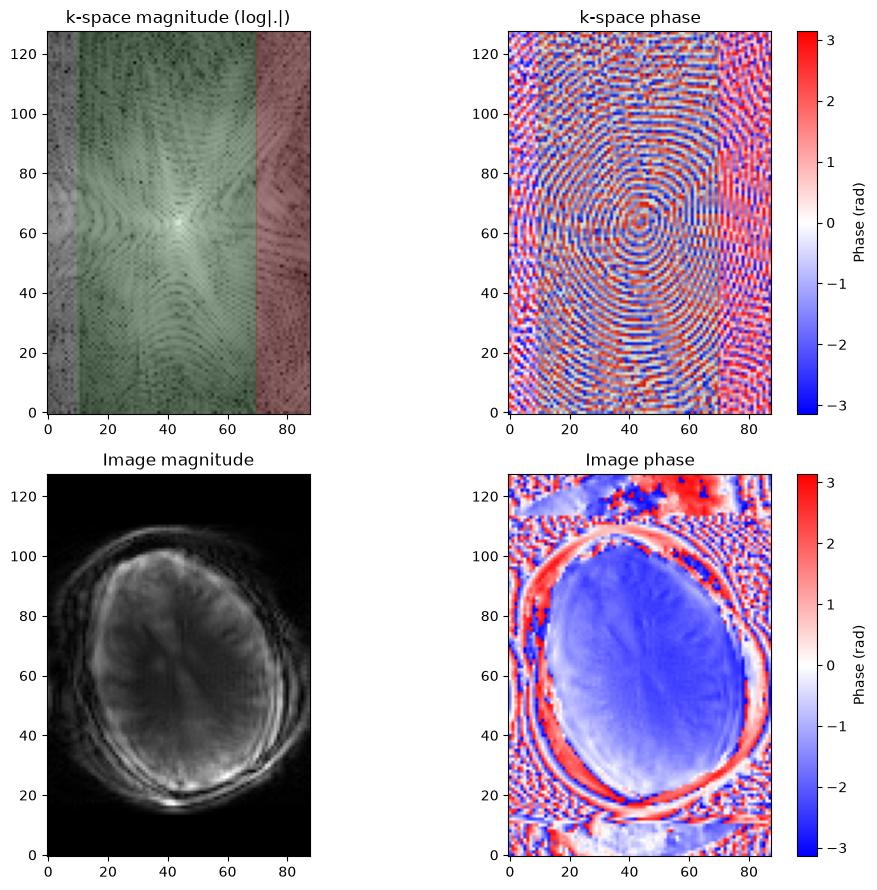

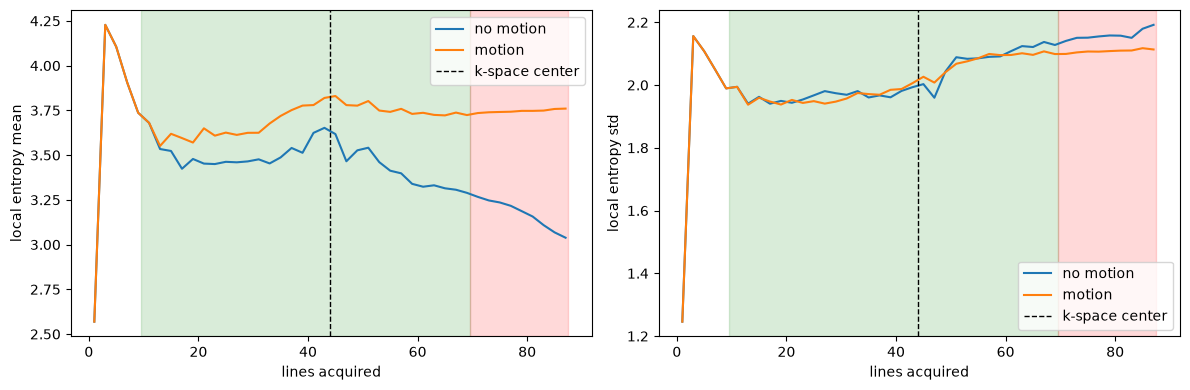

In [26]:
from skimage.filters.rank import entropy as local_entropy
from skimage.morphology import disk
from skimage.util import img_as_ubyte

b = np.abs(img_motion)
b_u8 = img_as_ubyte(b / b.max())
ent_map = local_entropy(b_u8, disk(5))
ent_mean, ent_std = ent_map.mean(), ent_map.std()

import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
import nibabel as nib

PHASE = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-phase_MTS.nii.gz")
MAG = ("./../data/sub-02_acq-qmtspgr_flip-1_mt-on_part-mag_MTS.nii.gz")

mag_data = (nib.load(MAG).get_fdata())[:, :, 0]
phase_data = (nib.load(PHASE).get_fdata())[:, :, 0]
complex_img = mag_data * np.exp(1j * phase_data)
kspace = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(complex_img)))  # centered k-space
nx, ny = kspace.shape

# Assuming one full Ky line per TR
motion_start = 10
motion_stop = 70
total_rot = 40  # deg
angle_rate = total_rot / max(motion_stop - motion_start - 1, 1)  # deg per line, last line reaches total_rot

lines = np.arange(nx)
x_deg = np.arange(motion_stop - motion_start)
deg = np.zeros(nx)
deg[(lines >= motion_start) & (lines < motion_stop)] = x_deg * angle_rate
kspace_rot = kspace.copy()

# during motion: one rotated image per line
for i in lines[motion_start:motion_stop]:
    complex_img_rotated = (
        rotate(complex_img.real, deg[i], reshape=False, order=1)
        + 1j * rotate(complex_img.imag, deg[i], reshape=False, order=1))
    kspace_rot[i, :] = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(complex_img_rotated)))[i, :]

# after motion: object stays at final angle -> rotate + FFT once
complex_img_rotated = (
    rotate(complex_img.real, deg[motion_stop - 1], reshape=False, order=1)
    + 1j * rotate(complex_img.imag, deg[motion_stop - 1], reshape=False, order=1))
kspace_rot[motion_stop:, :] = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(complex_img_rotated)))[motion_stop:, :]

img_motion = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(kspace_rot)))

fig, axes = plt.subplots(2, 2, figsize=(10, 9))

axes[0, 0].imshow(np.log(np.abs(kspace_rot) + 1e-9).T, cmap="gray", origin="lower")
axes[0, 0].set_title("k-space magnitude (log|.|)")

im = axes[0, 1].imshow(np.angle(kspace_rot).T, cmap="bwr", vmin=-np.pi, vmax=np.pi, origin="lower")
axes[0, 1].set_title("k-space phase")
fig.colorbar(im, ax=axes[0, 1], label="Phase (rad)")

# masks on k-space: green = moving, red = still but rotated
for ax in axes[0]:
    ax.axvspan(motion_start - 0.5, motion_stop - 0.5, color="green", alpha=0.15)
    ax.axvspan(motion_stop - 0.5, nx - 0.5, color="red", alpha=0.15)

axes[1, 0].imshow(np.abs(img_motion).T, cmap="gray", origin="lower")
axes[1, 0].set_title("Image magnitude")

im = axes[1, 1].imshow(np.angle(img_motion).T, cmap="bwr", vmin=-np.pi, vmax=np.pi, origin="lower")
axes[1, 1].set_title("Image phase")
fig.colorbar(im, ax=axes[1, 1], label="Phase (rad)")

plt.tight_layout()
plt.show()

def entropy_stats(k_full, n):
    k_partial = np.zeros_like(k_full)
    k_partial[:n, :] = k_full[:n, :]          # lines acquired so far
    b = np.abs(np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(k_partial))))
    b_u8 = img_as_ubyte(b / b.max())
    ent_map = local_entropy(b_u8, disk(5))
    return ent_map.mean(), ent_map.std()

step = 2                                      # compute every 2 lines (faster)
acq_lines = np.arange(1, nx + 1, step)
clean = np.array([entropy_stats(kspace, n) for n in acq_lines])
motion = np.array([entropy_stats(kspace_rot, n) for n in acq_lines])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, j, name in zip(axes, (0, 1), ("mean", "std")):
    ax.plot(acq_lines, clean[:, j], label="no motion")
    ax.plot(acq_lines, motion[:, j], label="motion")
    ax.axvspan(motion_start - 0.5, motion_stop - 0.5, color="green", alpha=0.15)
    ax.axvspan(motion_stop - 0.5, nx - 0.5, color="red", alpha=0.15)
    ax.axvline(nx // 2, color="k", ls="--", lw=1, label="k-space center")
    ax.set_xlabel("lines acquired")
    ax.set_ylabel(f"local entropy {name}")
    ax.legend()
plt.tight_layout()
plt.show()